<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Circuit_Topology_and_Schematic_Generation_with_NetworkX_Graphviz_Schemdraw_Pydot_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [3]:
!uv pip install -q networkx pydot schemdraw matplotlib graphviz

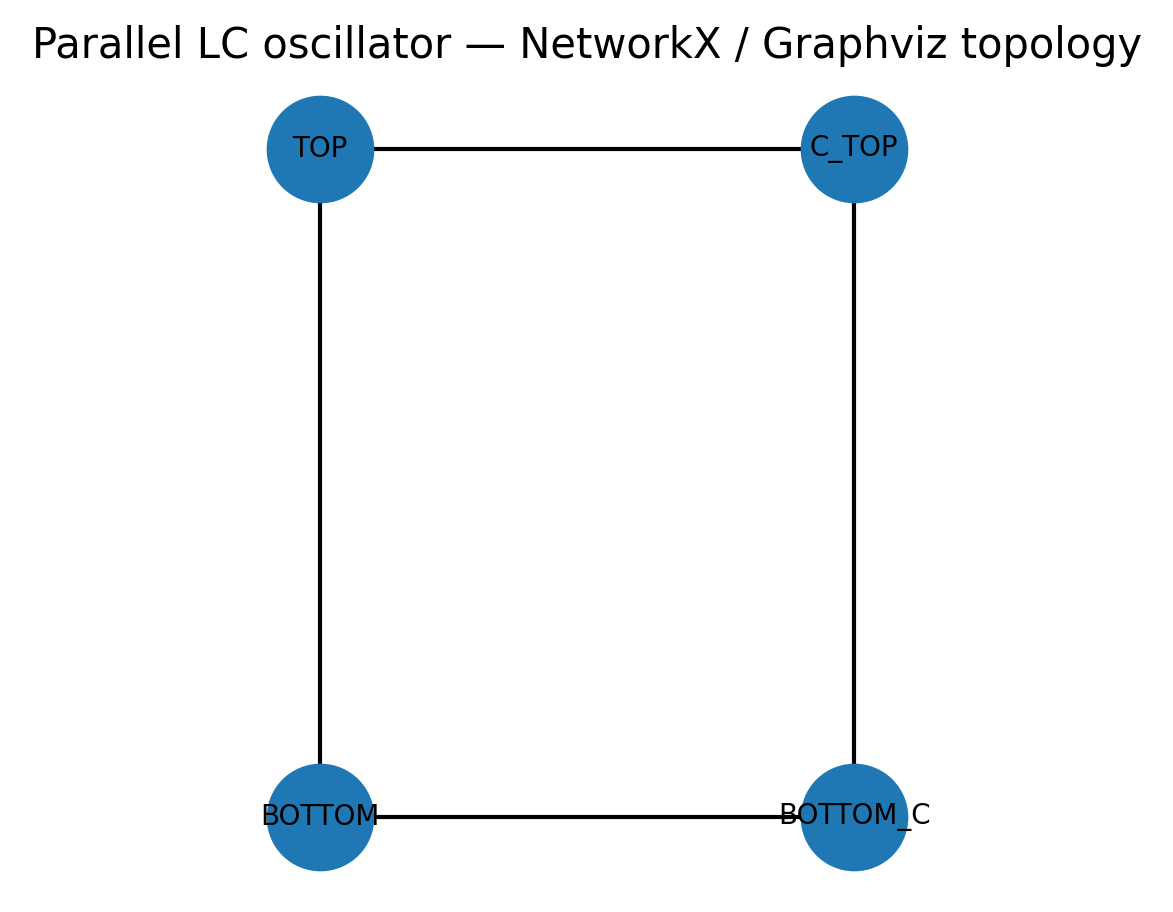

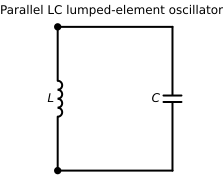

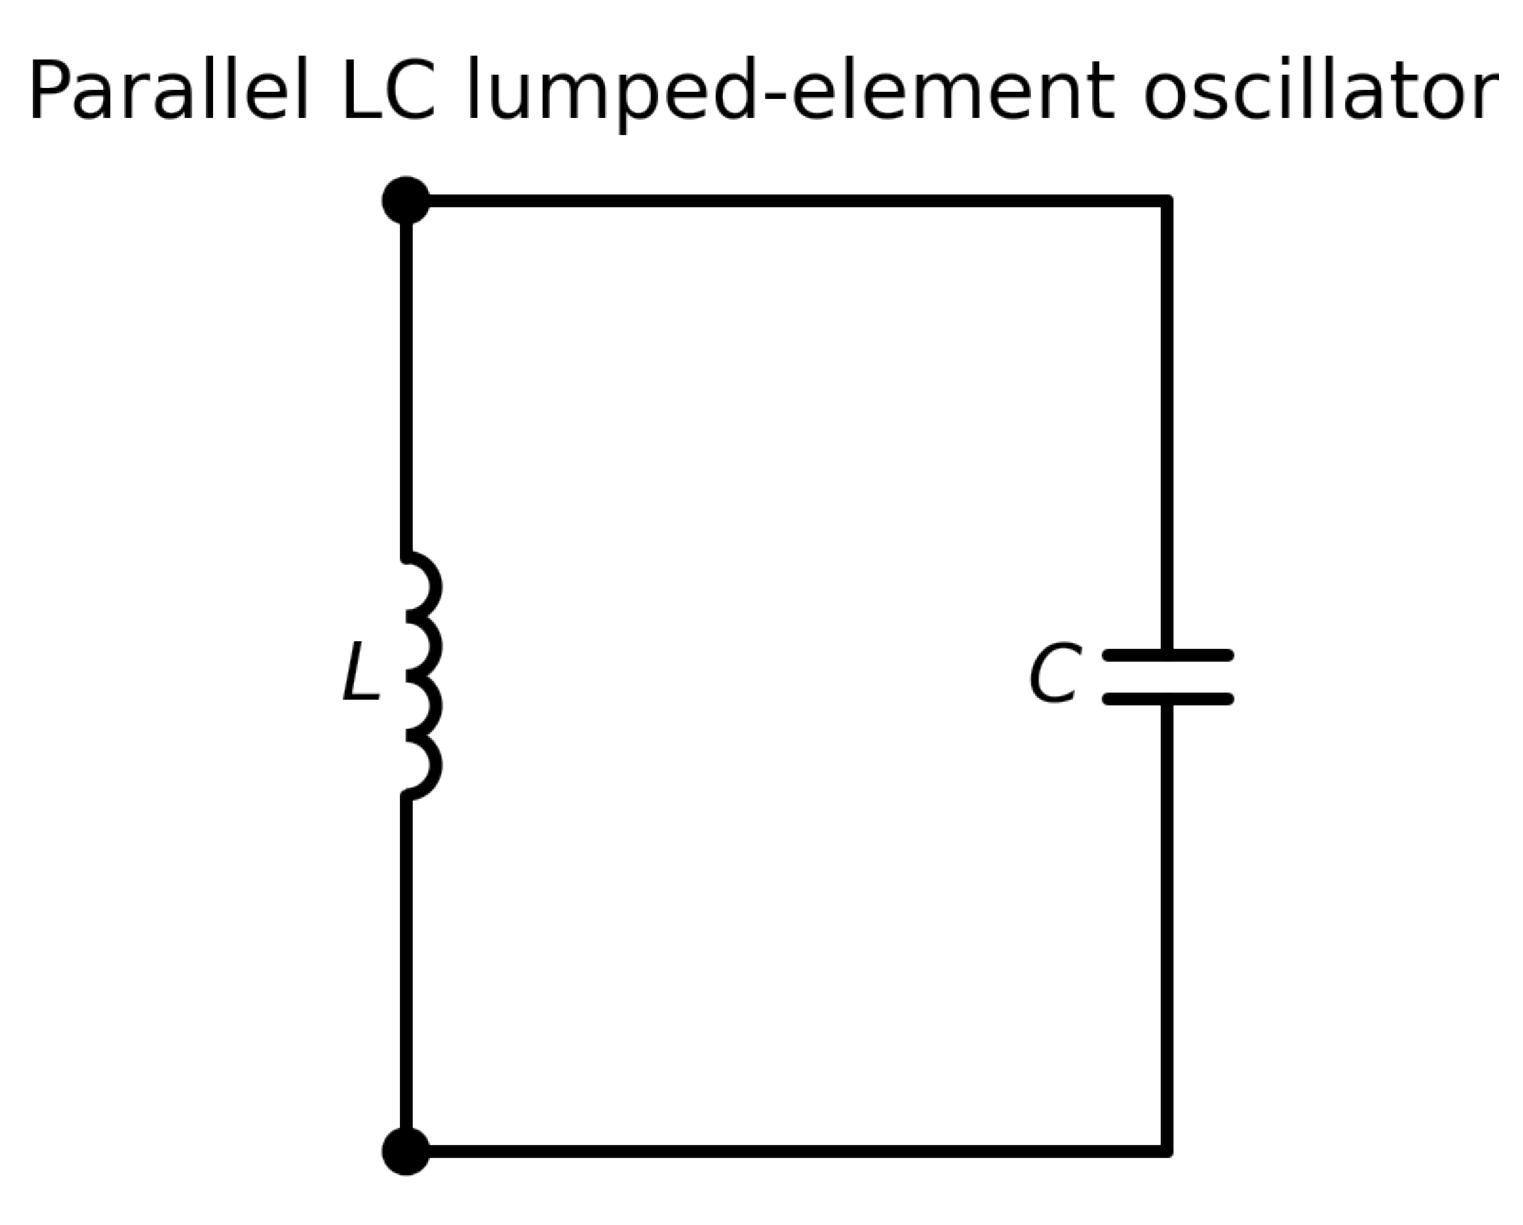

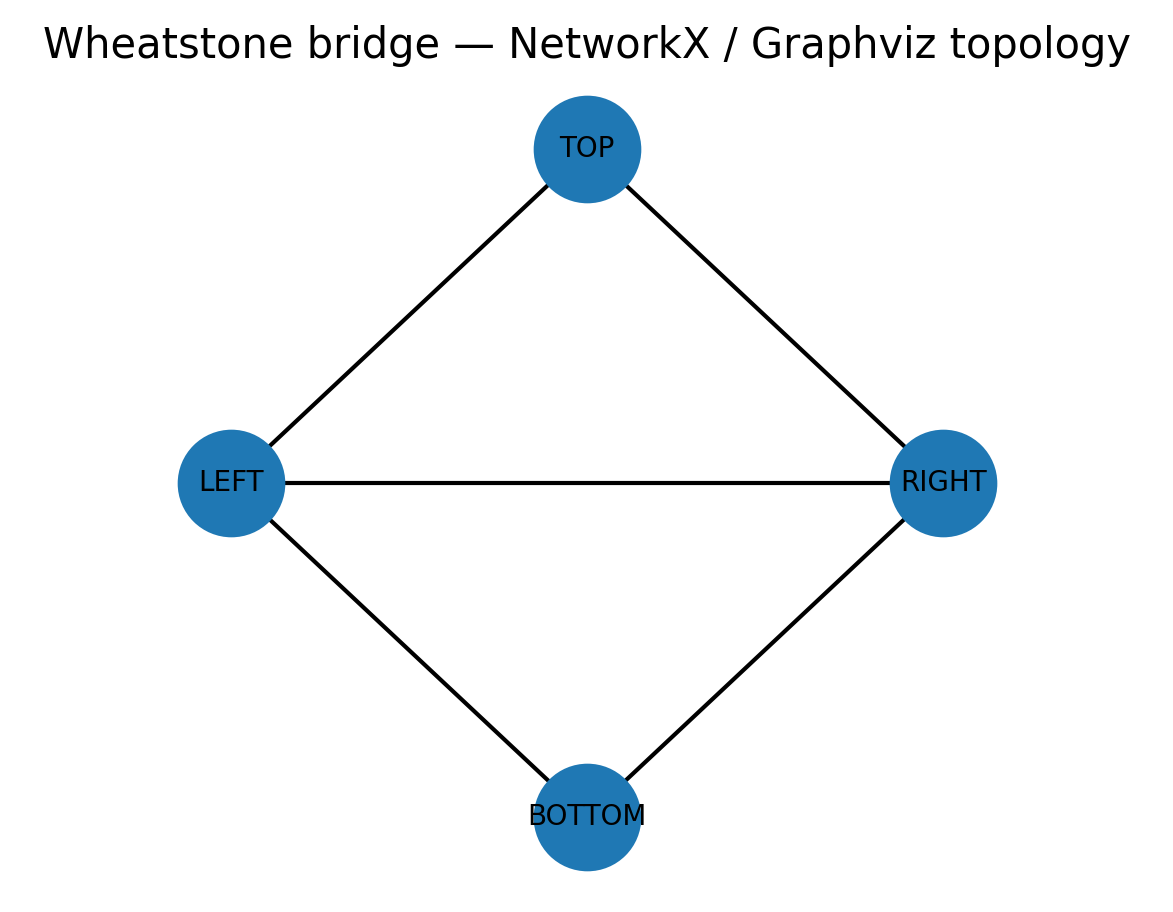

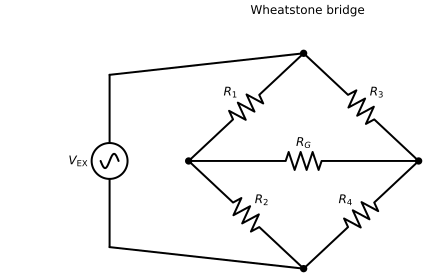

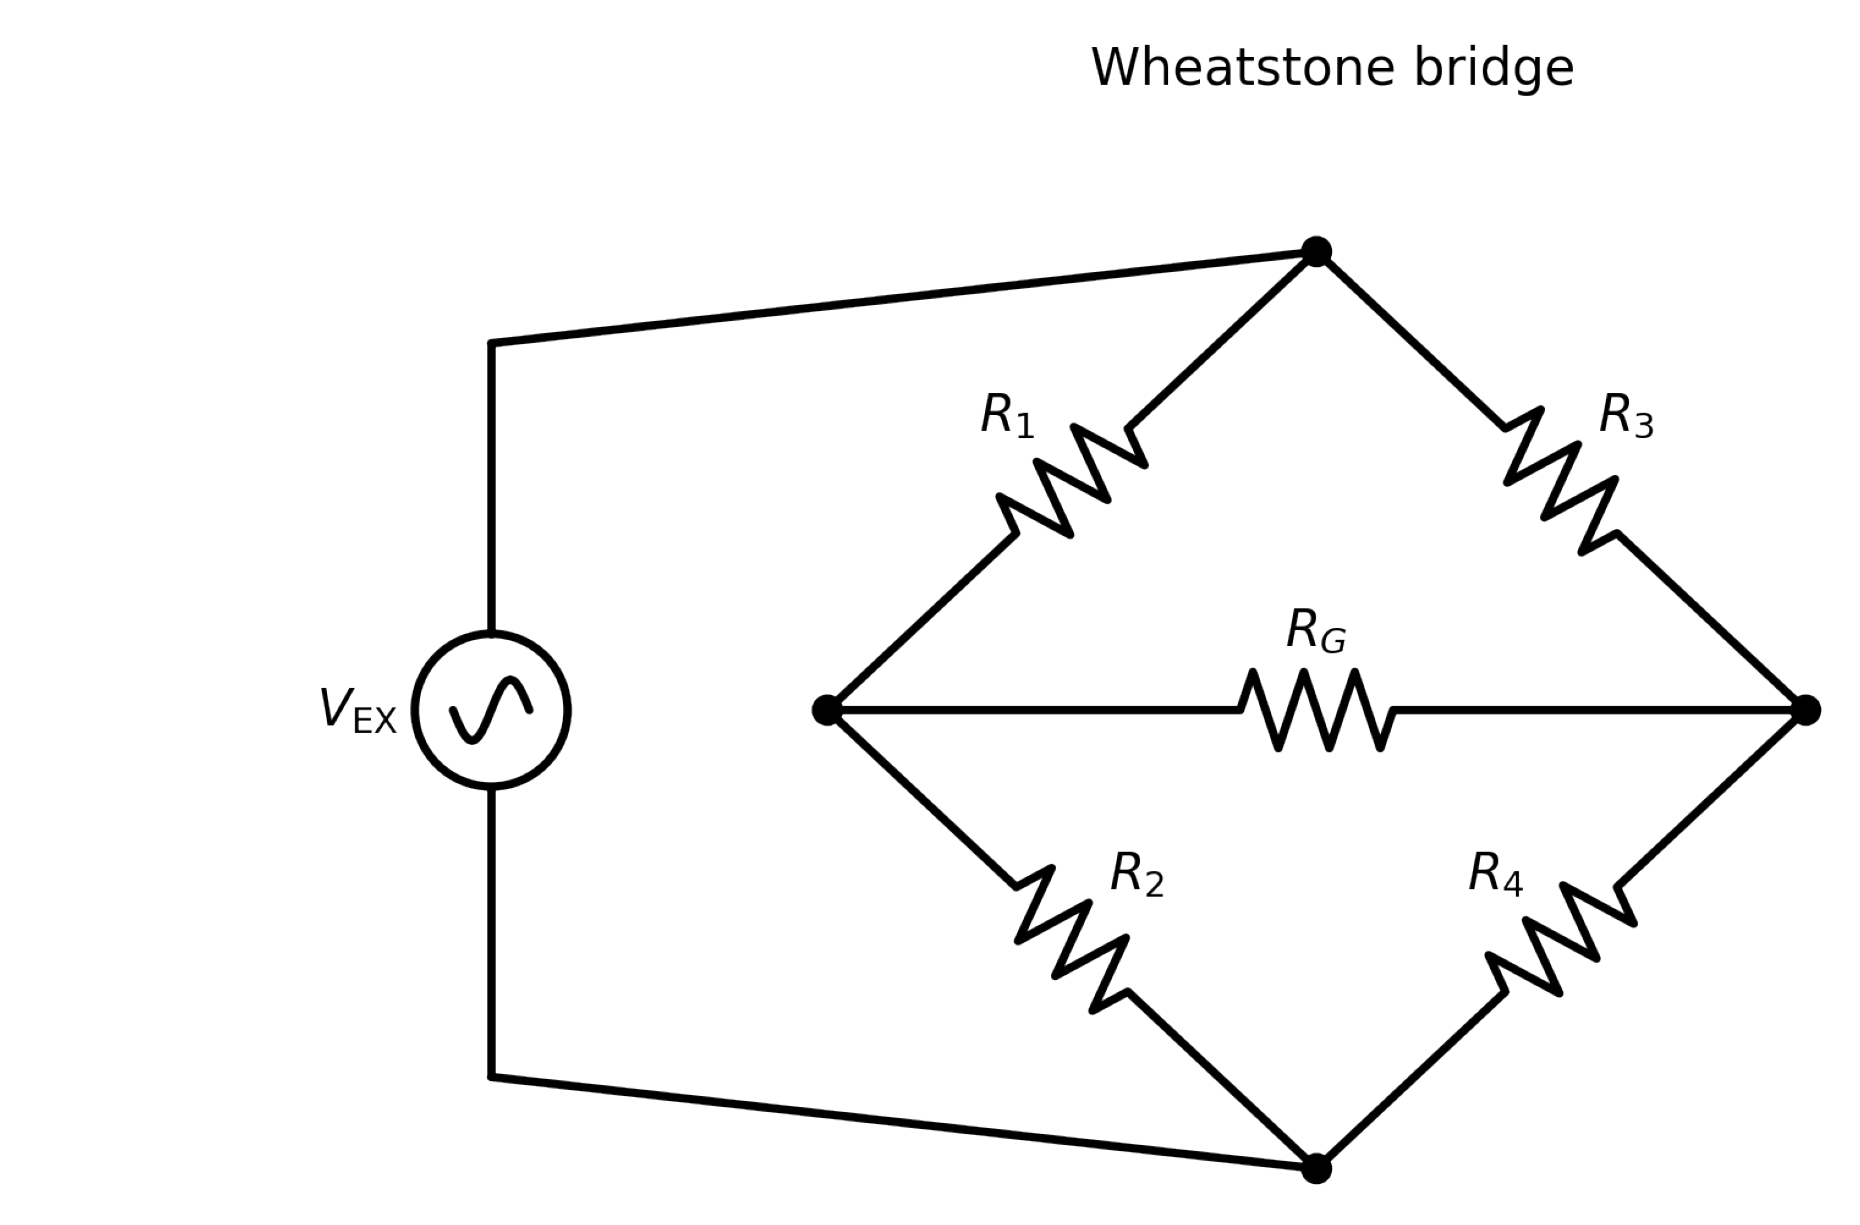

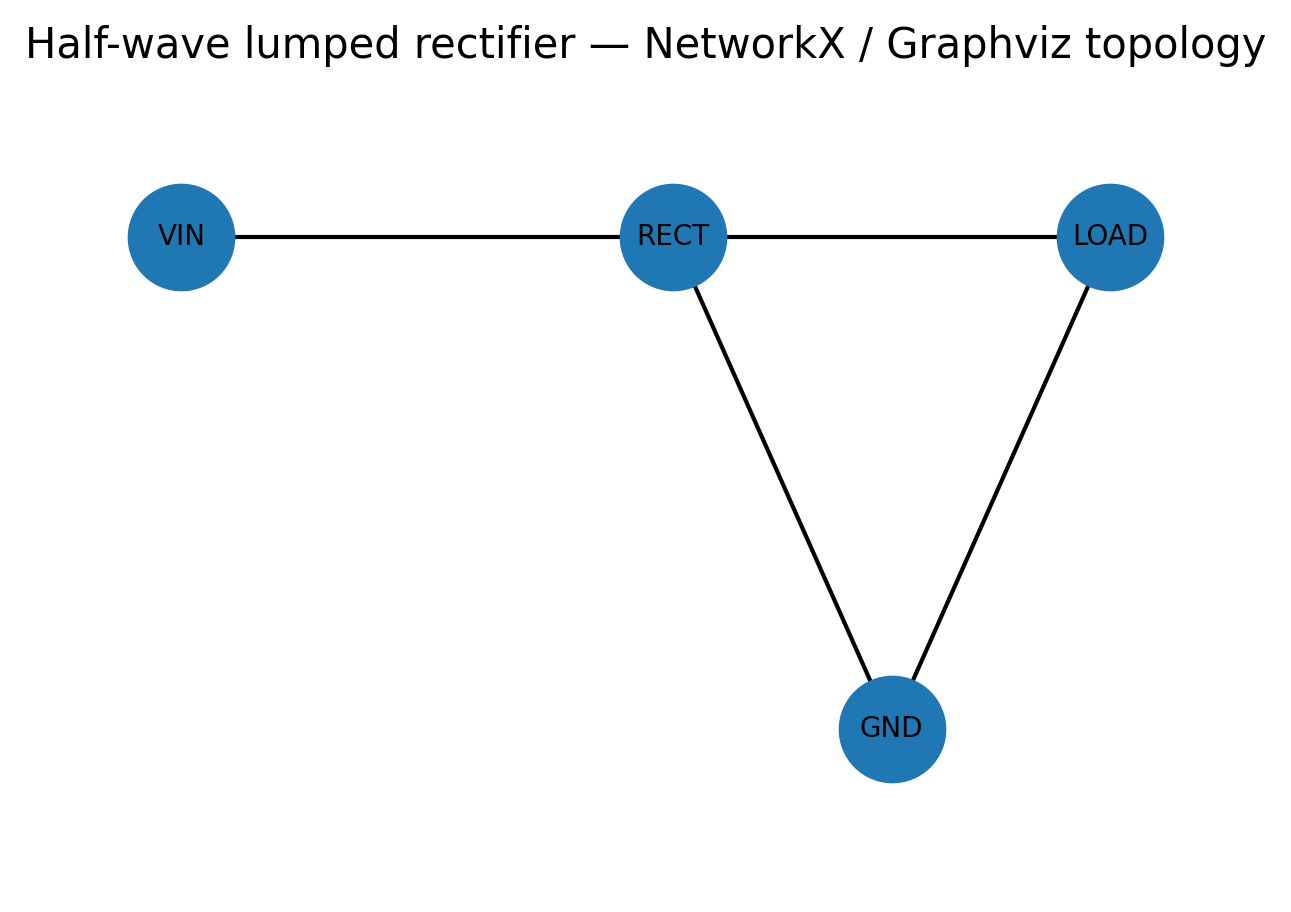

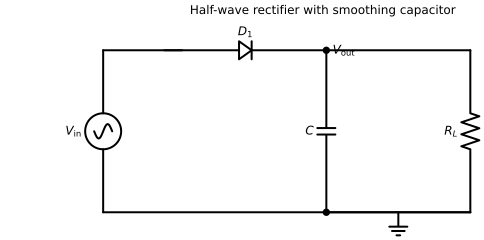

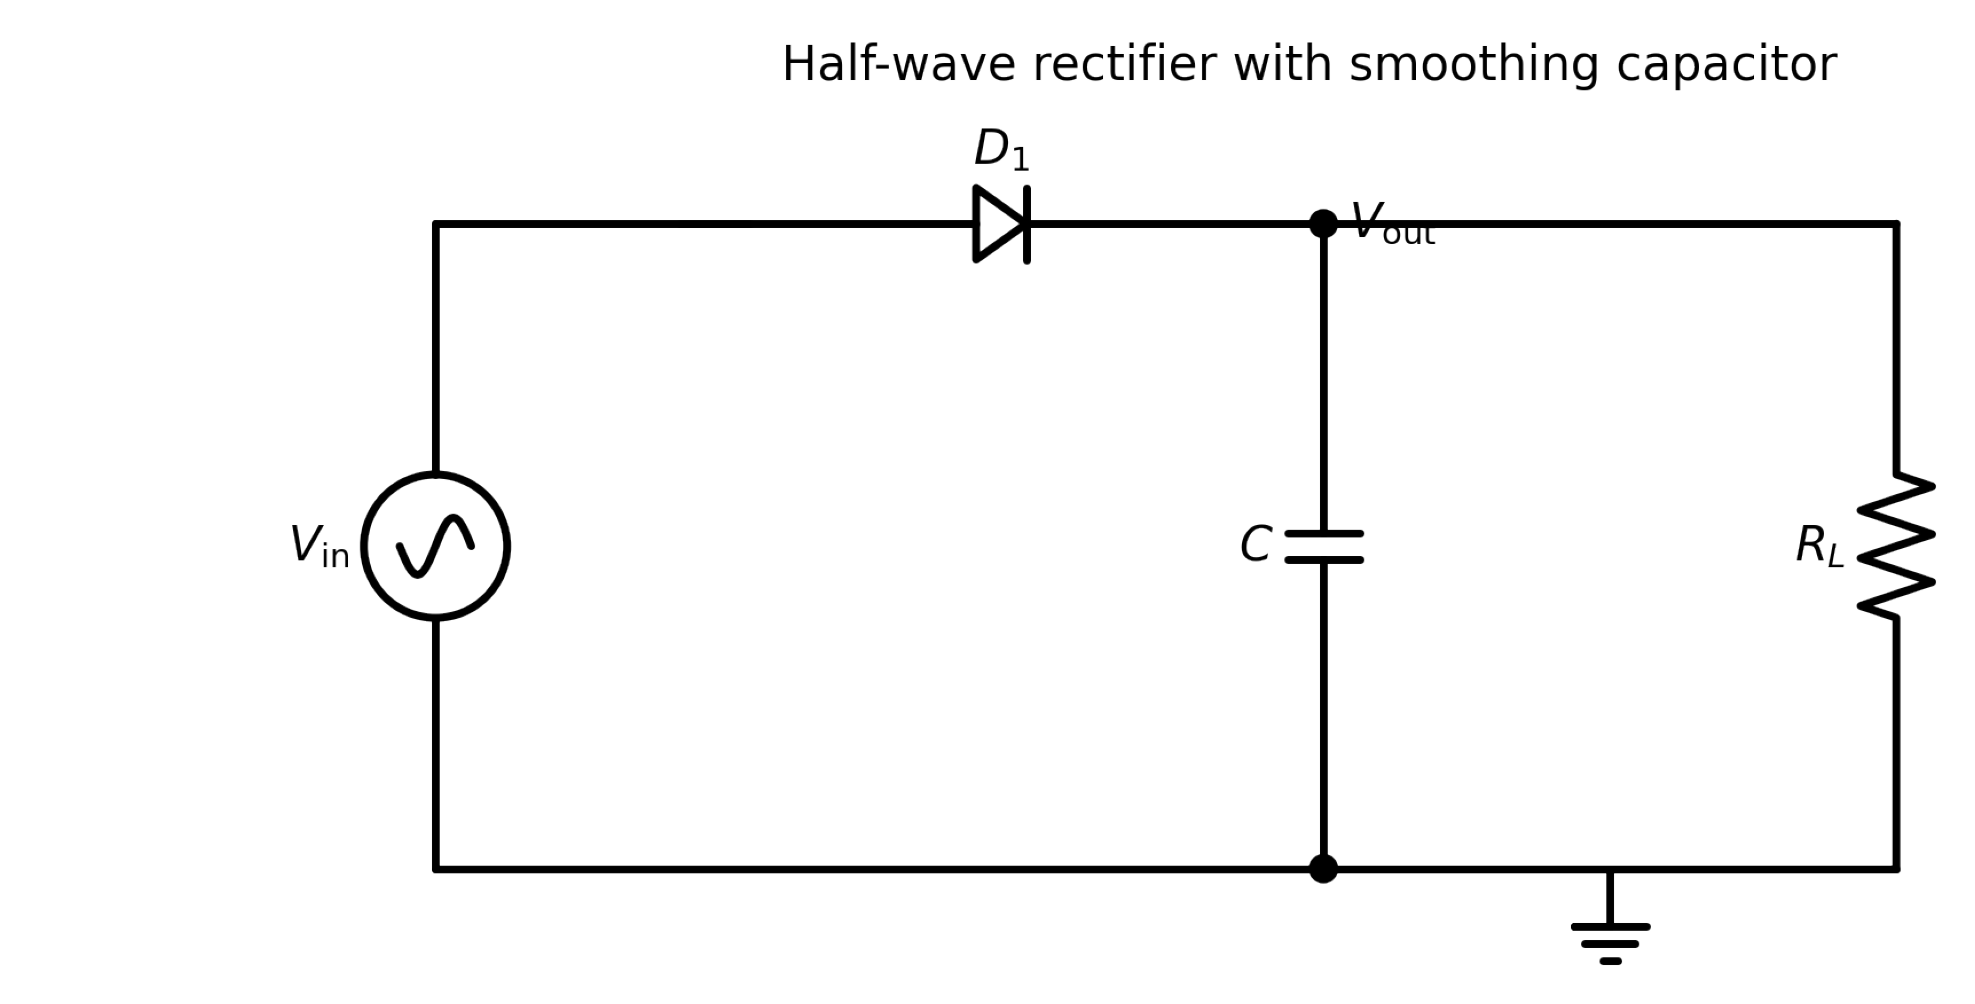


Generated files:
  /content/circuit_diagrams/01_lumped_element_oscillator.svg
  /content/circuit_diagrams/01_lumped_element_oscillator.png
  /content/circuit_diagrams/02_wheatstone_bridge.svg
  /content/circuit_diagrams/02_wheatstone_bridge.png
  /content/circuit_diagrams/03_lumped_element_rectifier.svg
  /content/circuit_diagrams/03_lumped_element_rectifier.png


In [4]:
# NetworkX + Graphviz + Schemdraw lumped-element circuit examples
#
# This Colab-ready script uses:
#   - NetworkX for electrical topology
#   - Graphviz for automatic node placement
#   - Schemdraw for actual lumped-element circuit symbols
#   - Matplotlib/IPython for in-memory previews
#   - Google Colab files.download for downloadable PNG/SVG outputs


# - Imports
import io
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import schemdraw
import schemdraw.elements as elm
from IPython.display import SVG, display

try:
    from google.colab import files
except ImportError:
    files = None

mpl.rcParams["figure.dpi"] = 250

# - Control knobs
OUTPUT_DIR = Path("/content/circuit_diagrams")
GRAPHVIZ_PROGRAM = "neato"
CANVAS_SCALE = 0.040
MIN_COMPONENT_LENGTH = 2.2
SHOW_GRAPHVIZ_TOPOLOGY = True
DISPLAY_SVG_PREVIEW = True
AUTO_DOWNLOAD = False
EXPORT_PNG = True
EXPORT_SVG = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def graphviz_positions(
    graph: nx.Graph,
    prog: str = GRAPHVIZ_PROGRAM,
    scale: float = CANVAS_SCALE,
) -> dict[str, tuple[float, float]]:
    """Compute automatic 2D node locations using Graphviz via pydot."""
    raw = nx.nx_pydot.graphviz_layout(graph, prog=prog)

    xs = [float(x) for x, _ in raw.values()]
    ys = [float(y) for _, y in raw.values()]
    x_mid = 0.5 * (min(xs) + max(xs))
    y_mid = 0.5 * (min(ys) + max(ys))

    positions = {
        str(node): (
            scale * (float(x) - x_mid),
            scale * (float(y) - y_mid),
        )
        for node, (x, y) in raw.items()
    }
    return positions


def remap_positions(
    positions: dict[str, tuple[float, float]],
    overrides: dict[str, tuple[float, float]],
) -> dict[str, tuple[float, float]]:
    """Apply optional geometric constraints after Graphviz placement."""
    mapped = dict(positions)
    mapped.update(overrides)
    return mapped


def point_distance(
    p1: tuple[float, float],
    p2: tuple[float, float],
) -> float:
    """Return Euclidean point-to-point distance."""
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    return (dx * dx + dy * dy) ** 0.5


def extended_endpoint(
    p1: tuple[float, float],
    p2: tuple[float, float],
    minimum_length: float = MIN_COMPONENT_LENGTH,
) -> tuple[float, float]:
    """Extend p2 if Graphviz places an edge too short for a visible symbol."""
    length = point_distance(p1, p2)
    if length >= minimum_length or length == 0:
        return p2

    scale = minimum_length / length
    return (
        p1[0] + scale * (p2[0] - p1[0]),
        p1[1] + scale * (p2[1] - p1[1]),
    )


def add_component(
    drawing: schemdraw.Drawing,
    kind: str,
    p1: tuple[float, float],
    p2: tuple[float, float],
    label: str = "",
) -> None:
    """Add a two-terminal lumped element between arbitrary coordinates."""
    p2 = extended_endpoint(p1, p2)

    component_map: dict[str, Any] = {
        "resistor": elm.Resistor,
        "capacitor": elm.Capacitor,
        "inductor": elm.Inductor,
        "diode": elm.Diode,
        "source_ac": elm.SourceSin,
        "wire": elm.Line,
    }

    if kind not in component_map:
        raise ValueError(f"Unsupported component kind: {kind}")

    element = component_map[kind]().at(p1).to(p2)

    if label:
        element = element.label(label)

    drawing += element


def add_dot(
    drawing: schemdraw.Drawing,
    point: tuple[float, float],
    label: str | None = None,
) -> None:
    """Add an electrical junction dot and optional node label."""
    dot = elm.Dot().at(point)
    if label:
        dot = dot.label(label, loc="right")
    drawing += dot


def preview_topology(
    graph: nx.Graph,
    positions: dict[str, tuple[float, float]],
    title: str,
) -> None:
    """Show the Graphviz-derived NetworkX topology used by the schematic."""
    if not SHOW_GRAPHVIZ_TOPOLOGY:
        return

    plt.figure(figsize=(5.8, 4.2))
    nx.draw_networkx(
        graph,
        pos=positions,
        with_labels=True,
        node_size=900,
        font_size=8,
        width=1.2,
    )
    plt.title(f"{title} — NetworkX / Graphviz topology")
    plt.axis("equal")
    plt.axis("off")
    plt.show()


def save_and_display(
    drawing: schemdraw.Drawing,
    stem: str,
) -> list[Path]:
    """Render, save, display, and optionally download a circuit drawing."""
    paths: list[Path] = []

    if EXPORT_SVG:
        svg_path = OUTPUT_DIR / f"{stem}.svg"
        drawing.save(str(svg_path))
        paths.append(svg_path)

        if DISPLAY_SVG_PREVIEW:
            display(SVG(filename=str(svg_path)))

    if EXPORT_PNG:
        png_path = OUTPUT_DIR / f"{stem}.png"
        drawing.save(str(png_path), dpi=250)
        paths.append(png_path)

        image = plt.imread(png_path)
        plt.figure(figsize=(8.0, 5.0))
        plt.imshow(image)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    if AUTO_DOWNLOAD and files is not None:
        for path in paths:
            files.download(str(path))

    return paths


def make_lumped_oscillator() -> list[Path]:
    """Create a parallel LC lumped-element oscillator."""
    graph = nx.Graph()
    graph.add_edge("TOP", "BOTTOM", kind="inductor", label="L")
    graph.add_edge("TOP", "BOTTOM_C", kind="capacitor", label="C")
    graph.add_edge("BOTTOM_C", "BOTTOM", kind="wire", label="")

    positions = graphviz_positions(graph, prog="neato")
    positions = remap_positions(
        positions,
        {
            "TOP": (0.0, 2.0),
            "BOTTOM": (0.0, -2.0),
            "BOTTOM_C": (3.2, -2.0),
        },
    )
    capacitor_top = (3.2, 2.0)

    preview_graph = nx.Graph()
    preview_graph.add_edges_from(
        [
            ("TOP", "BOTTOM"),
            ("TOP", "C_TOP"),
            ("C_TOP", "BOTTOM_C"),
            ("BOTTOM_C", "BOTTOM"),
        ]
    )
    preview_positions = dict(positions)
    preview_positions["C_TOP"] = capacitor_top
    preview_topology(
        preview_graph,
        preview_positions,
        "Parallel LC oscillator",
    )

    drawing = schemdraw.Drawing()
    drawing.config(unit=3.0, fontsize=12)

    add_component(
        drawing,
        "inductor",
        positions["TOP"],
        positions["BOTTOM"],
        r"$L$",
    )
    add_component(
        drawing,
        "wire",
        positions["TOP"],
        capacitor_top,
    )
    add_component(
        drawing,
        "capacitor",
        capacitor_top,
        positions["BOTTOM_C"],
        r"$C$",
    )
    add_component(
        drawing,
        "wire",
        positions["BOTTOM_C"],
        positions["BOTTOM"],
    )

    add_dot(drawing, positions["TOP"])
    add_dot(drawing, positions["BOTTOM"])

    drawing += elm.Label().at((1.6, 2.55)).label(
        r"Parallel LC lumped-element oscillator"
    )

    return save_and_display(drawing, "01_lumped_element_oscillator")


def make_wheatstone_bridge() -> list[Path]:
    """Create a Wheatstone bridge with source and detector branches."""
    graph = nx.Graph()
    graph.add_edge("TOP", "LEFT", kind="resistor", label="R1")
    graph.add_edge("LEFT", "BOTTOM", kind="resistor", label="R2")
    graph.add_edge("TOP", "RIGHT", kind="resistor", label="R3")
    graph.add_edge("RIGHT", "BOTTOM", kind="resistor", label="R4")
    graph.add_edge("LEFT", "RIGHT", kind="resistor", label="Rg")

    positions = graphviz_positions(graph, prog="neato")
    positions = remap_positions(
        positions,
        {
            "TOP": (0.0, 3.0),
            "LEFT": (-3.2, 0.0),
            "RIGHT": (3.2, 0.0),
            "BOTTOM": (0.0, -3.0),
        },
    )

    preview_topology(graph, positions, "Wheatstone bridge")

    drawing = schemdraw.Drawing()
    drawing.config(unit=3.0, fontsize=12)

    edges = [
        ("TOP", "LEFT", "resistor", r"$R_1$"),
        ("LEFT", "BOTTOM", "resistor", r"$R_2$"),
        ("TOP", "RIGHT", "resistor", r"$R_3$"),
        ("RIGHT", "BOTTOM", "resistor", r"$R_4$"),
        ("LEFT", "RIGHT", "resistor", r"$R_G$"),
    ]
    for start, stop, kind, label in edges:
        add_component(
            drawing,
            kind,
            positions[start],
            positions[stop],
            label,
        )

    source_top = (-5.4, 2.4)
    source_bottom = (-5.4, -2.4)
    add_component(
        drawing,
        "source_ac",
        source_bottom,
        source_top,
        r"$V_\mathrm{EX}$",
    )
    add_component(
        drawing,
        "wire",
        source_top,
        positions["TOP"],
    )
    add_component(
        drawing,
        "wire",
        source_bottom,
        positions["BOTTOM"],
    )

    for node in ("TOP", "LEFT", "RIGHT", "BOTTOM"):
        add_dot(drawing, positions[node])

    drawing += elm.Label().at((0.0, 4.1)).label(
        r"Wheatstone bridge"
    )

    return save_and_display(drawing, "02_wheatstone_bridge")


def make_lumped_rectifier() -> list[Path]:
    """Create a half-wave lumped rectifier with capacitor smoothing."""
    graph = nx.Graph()
    graph.add_edge("VIN", "RECT", kind="diode", label="D1")
    graph.add_edge("RECT", "GND", kind="capacitor", label="C")
    graph.add_edge("RECT", "LOAD", kind="resistor", label="RL")
    graph.add_edge("LOAD", "GND", kind="wire", label="")

    positions = graphviz_positions(graph, prog="dot")
    positions = remap_positions(
        positions,
        {
            "VIN": (-4.5, 2.0),
            "RECT": (0.0, 2.0),
            "LOAD": (4.0, 2.0),
            "GND": (2.0, -2.5),
        },
    )

    preview_topology(graph, positions, "Half-wave lumped rectifier")

    drawing = schemdraw.Drawing()
    drawing.config(unit=3.0, fontsize=12)

    source_top = (-6.2, 2.0)
    source_bottom = (-6.2, -2.5)

    add_component(
        drawing,
        "source_ac",
        source_bottom,
        source_top,
        r"$V_\mathrm{in}$",
    )
    add_component(
        drawing,
        "wire",
        source_top,
        positions["VIN"],
    )
    add_component(
        drawing,
        "diode",
        positions["VIN"],
        positions["RECT"],
        r"$D_1$",
    )

    cap_bottom = (0.0, -2.5)
    add_component(
        drawing,
        "capacitor",
        positions["RECT"],
        cap_bottom,
        r"$C$",
    )

    add_component(
        drawing,
        "wire",
        positions["RECT"],
        positions["LOAD"],
    )
    add_component(
        drawing,
        "resistor",
        positions["LOAD"],
        (4.0, -2.5),
        r"$R_L$",
    )

    add_component(
        drawing,
        "wire",
        source_bottom,
        (4.0, -2.5),
    )
    add_component(
        drawing,
        "wire",
        cap_bottom,
        (4.0, -2.5),
    )

    add_dot(drawing, positions["RECT"], r"$V_\mathrm{out}$")
    add_dot(drawing, cap_bottom)
    drawing += elm.Ground().at((2.0, -2.5))

    drawing += elm.Label().at((-0.2, 3.0)).label(
        r"Half-wave rectifier with smoothing capacitor"
    )

    return save_and_display(drawing, "03_lumped_element_rectifier")


def download_all(paths: list[Path]) -> None:
    """Download all generated files in Google Colab."""
    if files is None:
        print("google.colab.files is unavailable outside Colab.")
        return

    for path in paths:
        files.download(str(path))


all_paths: list[Path] = []
all_paths.extend(make_lumped_oscillator())
all_paths.extend(make_wheatstone_bridge())
all_paths.extend(make_lumped_rectifier())

print("\nGenerated files:")
for generated_path in all_paths:
    print(f"  {generated_path}")

# Optional manual download:
# download_all(all_paths)